In [12]:
time_stamp = []
with open("TopRight_20230803.txt", "r") as data:
    for line in data:

        line = line.strip()
        if not line:
            continue

        if line.startswith('#'):
            continue

        columns = line.split()

        if len(columns) >= 4:
            time_stamp_value = int(columns[3])
            time_stamp.append(time_stamp_value)

print(time_stamp[:5])
print(time_stamp_value, "\n")

print(len(time_stamp))

[609, 1891, 2324, 2382, 2552]
318579019 

763301


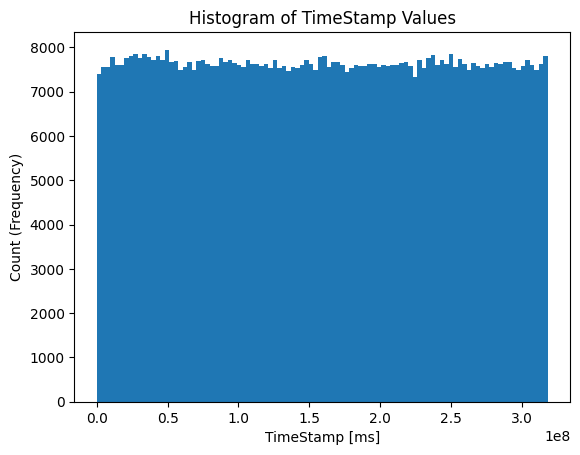

In [14]:
import matplotlib.pyplot as plt

plt.hist(time_stamp, bins = 100)

plt.xlabel('TimeStamp [ms]')
plt.ylabel('Count (Frequency)')
plt.title('Histogram of TimeStamp Values')

plt.show()

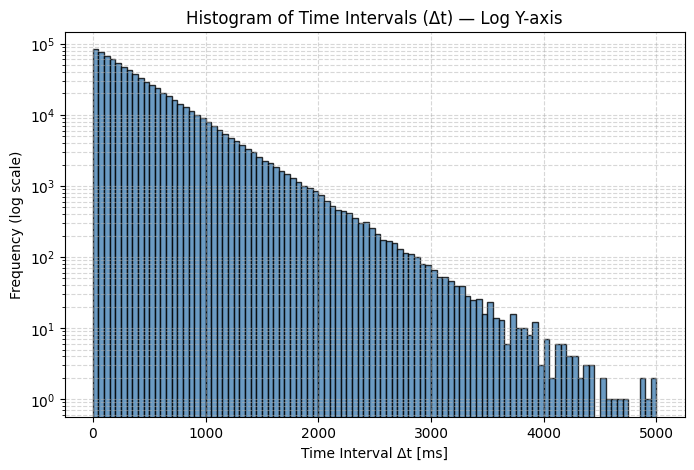

In [16]:
import numpy as np

# 计算相邻时间戳的差值 → 得到时间间隔列表（单位：ms）
time_deltas = np.diff(time_stamp)  # 长度 = len(time_stamp) - 1 ≈ 729,999

import matplotlib.pyplot as plt

# 推荐：用对数纵轴（log scale），因为指数衰减在普通坐标下后面几乎贴着x轴看不清
plt.figure(figsize=(8, 5))
plt.hist(time_deltas, bins=100, range=(0, 5000), alpha=0.8, color='steelblue', edgecolor='black')

plt.xlabel('Time Interval Δt [ms]')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Time Intervals (Δt) — Log Y-axis')
plt.yscale('log')  # 👈 这行让指数衰减特征一目了然！

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [17]:
# 事件率
event_rate = len(time_stamp) / (time_stamp[-1] / 1000)
print(event_rate)

2.3959550205030924


In [18]:
import numpy as np

# 假设 time_stamp 是你已有的 NumPy 数组或 Python 列表
# 单位：毫秒（ms），且已经按时间顺序排列（通常原始数据就是有序的）

# 确保是 NumPy 数组（如果不是）
time_stamp = np.array(time_stamp)

# 总采集时间（取最后一个时间戳，单位 ms）
total_time_ms = time_stamp[-1]  # 因为 t=0 开始，所以最后一个 ≈ 总时长

# 分成 100 个等宽的时间 bin
num_bins = 100
bin_edges = np.linspace(0, total_time_ms, num_bins + 1)  # 生成 101 个边界点

# 统计每个 bin 中有多少个事件
counts, _ = np.histogram(time_stamp, bins=bin_edges)

# 每个 bin 的时间长度（转换为秒）
bin_width_sec = (total_time_ms / num_bins) / 1000.0  # 先除以100得每bin多少ms，再/1000变秒

# 计算每个 bin 的事件率（events per second）
rates = counts / bin_width_sec

# 计算均值和标准差
mean_rate = np.mean(rates)
std_rate = np.std(rates, ddof=0)  # 总体标准差（题目没说样本，用默认即可）

# 计算相对统计不确定度 = 变异系数（Coefficient of Variation）
relative_uncertainty = std_rate / mean_rate

# 输出结果
print(f"总事件数: {len(time_stamp)}")
print(f"总采集时间: {total_time_ms / 1000:.1f} 秒 ({total_time_ms / 1000 / 3600:.2f} 小时)")
print(f"平均事件率: {mean_rate:.3f} events/second")
print(f"相对统计不确定度 (CV): {relative_uncertainty:.4f}")
print(f"即: {relative_uncertainty * 100:.2f}%")

总事件数: 763301
总采集时间: 318579.0 秒 (88.49 小时)
平均事件率: 2.396 events/second
相对统计不确定度 (CV): 0.0139
即: 1.39%
